# RQ1: Do SHAP value distributions differ statistically and significantly between honest and malicious clients in a federated learning environment under attacks?

## Setup

Adult Income dataset (~867 samples per client)

30 clients, IID split

6 malicious, 24 honest

All clients participate every round

30 rounds

Label-flip attack, Poison Fraction 10%, 20% malicious ratio

In [233]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [234]:
print(os.getcwd())

/home/b-fatma/master/federated/analysis


In [235]:
# Placeholder loading logic for shap_history from common formats
shap_history = None

# Preferred directory for SHAP outputs
preferred_dir = os.path.join(os.getcwd(), "../experiments", "shap_outputs")

TARGET_RUN_NAME = "FEDAVG_mlp_adult-income-census_r10_c30_ep3_lr0.001_bs8_iid_attack_mpaf_lambda0.3_ratio0.1"
TARGET_RUN_NAME = "FEDAVG_mlp_adult-income-census_r10_c30_ep3_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0_ratio0.5"
run_dir = (
    os.path.join(preferred_dir, TARGET_RUN_NAME) if TARGET_RUN_NAME else preferred_dir
)


def _coerce_round(value, fallback=None):
    try:
        return int(value)
    except Exception:
        return fallback


def _extract_round_from_path(path):
    for part in path.split(os.sep):
        if part.startswith("round_"):
            return _coerce_round(part.replace("round_", ""), fallback=None)
    return None


def _extract_client_from_path(path):
    for part in path.split(os.sep):
        if part.startswith("client_"):
            return part
    return None


def _load_vector_from_npz(npz_path):
    z = np.load(npz_path, allow_pickle=True)
    if "values" in z:
        arr = np.asarray(z["values"])
    else:
        keys = list(z.keys())
        if len(keys) == 0:
            return None
        arr = np.asarray(z[keys[0]])

    if arr.ndim == 0:
        vec = np.array([float(arr)])
    elif arr.ndim == 1:
        vec = arr
    else:
        vec = np.mean(arr, axis=0)
    return np.asarray(vec).reshape(-1)


if os.path.isdir(run_dir):
    parsed = {}
    npz_paths = sorted(
        glob.glob(os.path.join(run_dir, "**", "shap_values.npz"), recursive=True)
    )
    for npz_path in npz_paths:
        try:
            round_num = _extract_round_from_path(npz_path)
            client_id = _extract_client_from_path(npz_path)
            if round_num is None or client_id is None:
                continue

            vec = _load_vector_from_npz(npz_path)
            if vec is None:
                continue

            meta_path = os.path.join(os.path.dirname(npz_path), "metadata.json")
            is_malicious = False
            client_identifier = client_id
            if os.path.exists(meta_path):
                try:
                    with open(meta_path, "r") as f:
                        meta = json.load(f)
                    is_malicious = bool(
                        meta.get("malicious", meta.get("is_malicious", False))
                    )
                    client_identifier = str(meta.get("client_identifier", client_id))
                    round_num = _coerce_round(
                        meta.get("round_number", round_num), fallback=round_num
                    )
                except Exception:
                    pass

            parsed.setdefault(round_num, {})[client_identifier] = {
                "shap_values": vec,
                "is_malicious": is_malicious,
            }
        except Exception:
            continue
    if parsed:
        shap_history = parsed

if shap_history is None:
    shap_history = {}

In [236]:
# Helper utilities


def _safe_skew(values):
    """Unbiased skewness; returns NaN for fewer than 3 observations."""
    values = np.asarray(values)
    if values.size <= 2:
        return np.nan
    value = stats.skew(values, bias=False)
    return float(value) if np.isfinite(value) else np.nan


def flatten_shap_history(shap_history):
    flat = []
    for rnd, clients in shap_history.items():
        for client_id, entry in clients.items():
            sv = entry.get("shap_values") if isinstance(entry, dict) else None
            is_mal = entry.get("is_malicious") if isinstance(entry, dict) else False
            if sv is None:
                continue
            sv = np.asarray(sv)
            flat.append(
                {
                    "round": int(rnd),
                    "client_id": str(client_id),
                    "is_malicious": bool(is_mal),
                    "shap_values": sv,
                }
            )
    return flat


def compute_shap_statistics(flat_list):
    """
    Compute per-client-per-round scalar summaries of SHAP vectors.
    FIX: shap_variance now uses sample variance (ddof=1) for consistency
    with the sample std used in all summary tables.
    FIX: shap_skewness added so all four metrics are available in df_stats.
    """
    rows = []
    for item in flat_list:
        sv = item["shap_values"]
        rows.append(
            {
                "round": item["round"],
                "client_id": item["client_id"],
                "is_malicious": item["is_malicious"],
                "mean_abs_shap": float(np.mean(np.abs(sv))),
                "shap_variance": float(
                    np.var(sv, ddof=1)
                ),  # FIX: ddof=1 (sample variance)
                "shap_norm": float(np.linalg.norm(sv)),
                "shap_skewness": _safe_skew(sv),  # FIX: added skewness
            }
        )
    return pd.DataFrame(rows)


def build_feature_matrix(flat_list):
    """Stack SHAP vectors into an (n_observations x n_features) matrix."""
    lengths = [len(x["shap_values"]) for x in flat_list] if flat_list else []
    if len(set(lengths)) > 1:
        maxlen = max(lengths)
        X = np.zeros((len(flat_list), maxlen))
        for i, x in enumerate(flat_list):
            arr = np.asarray(x["shap_values"])
            X[i, : len(arr)] = arr
    else:
        X = (
            np.vstack([np.asarray(x["shap_values"]) for x in flat_list])
            if flat_list
            else np.zeros((0, 0))
        )
    y = (
        np.array([bool(x["is_malicious"]) for x in flat_list])
        if flat_list
        else np.array([])
    )
    meta = [
        {
            "round": int(x["round"]),
            "client_id": x["client_id"],
            "is_malicious": bool(x["is_malicious"]),
        }
        for x in flat_list
    ]
    return X, y, meta

In [237]:
# Build dataframe of statistics and feature matrix
flat = flatten_shap_history(shap_history)
df_stats = compute_shap_statistics(flat)

if not df_stats.empty:
    df_stats["label"] = df_stats["is_malicious"].map(
        {True: "malicious", False: "benign"}
    )
else:
    df_stats = df_stats.reindex(
        columns=[
            "round",
            "client_id",
            "is_malicious",
            "mean_abs_shap",
            "shap_variance",
            "shap_norm",
            "shap_skewness",
            "label",
        ]
    )

X, y, meta = build_feature_matrix(flat)

# Unified metric list used consistently across all analysis blocks
ALL_METRICS = ["mean_abs_shap", "shap_variance", "shap_norm", "shap_skewness"]

In [238]:
# Distribution characterization by client type
# FIX: ALL_METRICS used consistently across all three summary tables.
# FIX: df_client_level removed — df_stats now contains all four metrics,
#      so a duplicate per-client frame is unnecessary.

if df_stats.empty or X.size == 0:
    df_distribution_summary = pd.DataFrame(
        columns=[
            "label",
            "metric",
            "count",
            "mean",
            "std",
            "median",
            "q1",
            "q3",
            "iqr",
            "skew",
            "kurtosis",
        ]
    )
    df_feature_group_summary = pd.DataFrame(
        columns=[
            "label",
            "feature_index",
            "metric",
            "mean",
            "std",
            "median",
            "q1",
            "q3",
            "iqr",
            "skew",
        ]
    )
    df_group_deltas = pd.DataFrame(
        columns=[
            "metric",
            "benign_median",
            "malicious_median",
            "median_diff",
            "benign_mean",
            "malicious_mean",
            "mean_diff",
        ]
    )
else:
    # ── Aggregated distribution summary (all rounds × all clients) ────────────
    rows = []
    for label, group in df_stats.groupby("label"):
        for metric in ALL_METRICS:
            values = group[metric].dropna().to_numpy()
            if values.size == 0:
                continue
            q1 = float(np.quantile(values, 0.25))
            q3 = float(np.quantile(values, 0.75))
            rows.append(
                {
                    "label": label,
                    "metric": metric,
                    "count": int(values.size),
                    "mean": float(np.mean(values)),
                    "std": float(np.std(values, ddof=1)) if values.size > 1 else 0.0,
                    "median": float(np.median(values)),
                    "q1": q1,
                    "q3": q3,
                    "iqr": float(q3 - q1),
                    "skew": _safe_skew(values),
                    "kurtosis": float(stats.kurtosis(values, bias=False))
                    if values.size > 3
                    else np.nan,
                }
            )
    df_distribution_summary = pd.DataFrame(rows)

    # ── Per-feature SHAP summary ──────────────────────────────────────────────
    feature_summary_rows = []
    for group_label, group_mask in [("benign", ~y), ("malicious", y)]:
        X_group = X[group_mask]
        if X_group.size == 0:
            continue
        for feature_index in range(X_group.shape[1]):
            values = X_group[:, feature_index]
            if values.size == 0:
                continue
            q1 = float(np.quantile(values, 0.25))
            q3 = float(np.quantile(values, 0.75))
            feature_summary_rows.append(
                {
                    "label": group_label,
                    "feature_index": int(feature_index),
                    "metric": "shap_value",
                    "mean": float(np.mean(values)),
                    "std": float(np.std(values, ddof=1)) if values.size > 1 else 0.0,
                    "median": float(np.median(values)),
                    "q1": q1,
                    "q3": q3,
                    "iqr": float(q3 - q1),
                    "skew": _safe_skew(values),
                }
            )
    df_feature_group_summary = pd.DataFrame(feature_summary_rows)

    # ── Group-level median / mean deltas (same ALL_METRICS) ──────────────────
    group_deltas_rows = []
    for metric in ALL_METRICS:
        benign_values = (
            df_stats.loc[df_stats["label"] == "benign", metric].dropna().to_numpy()
        )
        malicious_values = (
            df_stats.loc[df_stats["label"] == "malicious", metric].dropna().to_numpy()
        )
        if benign_values.size == 0 or malicious_values.size == 0:
            continue
        group_deltas_rows.append(
            {
                "metric": metric,
                "benign_median": float(np.median(benign_values)),
                "malicious_median": float(np.median(malicious_values)),
                "median_diff": float(
                    np.median(benign_values) - np.median(malicious_values)
                ),
                "benign_mean": float(np.mean(benign_values)),
                "malicious_mean": float(np.mean(malicious_values)),
                "mean_diff": float(np.mean(benign_values) - np.mean(malicious_values)),
            }
        )
    df_group_deltas = pd.DataFrame(group_deltas_rows)

    display(
        df_distribution_summary.sort_values(["metric", "label"]).reset_index(drop=True)
    )
    display(
        df_feature_group_summary.sort_values(["feature_index", "label"]).reset_index(
            drop=True
        )
    )
    display(df_group_deltas.sort_values("metric").reset_index(drop=True))

,label,metric,count,mean,std,median,q1,q3,iqr,skew,kurtosis
0,benign,mean_abs_shap,150,0.018267,0.003059,0.018853,0.016222,0.020245,0.004023,-0.638272,0.969586
1,malicious,mean_abs_shap,150,0.014924,0.002845,0.014916,0.013100,0.016216,0.003116,0.256318,0.022400
2,benign,shap_norm,150,0.201779,0.035521,0.205300,0.183802,0.223403,0.039601,-0.571701,0.576337
3,malicious,shap_norm,150,0.155010,0.034568,0.146968,0.131719,0.171018,0.039300,0.936998,0.704533
4,benign,shap_skewness,150,-2.660790,0.616097,-2.658964,-2.957311,-2.296956,0.660355,0.001731,0.983199
5,malicious,shap_skewness,150,-2.566703,0.913758,-2.588411,-3.135395,-1.988432,1.146963,-0.042313,-0.060080
6,benign,shap_variance,150,0.001311,0.000433,0.001322,0.001065,0.001578,0.000513,0.103554,0.195235
7,malicious,shap_variance,150,0.000797,0.000378,0.000696,0.000555,0.000926,0.000370,1.464633,1.961258


,label,feature_index,metric,mean,std,median,q1,q3,iqr,skew
0,benign,0,shap_value,0.020560,0.010863,0.019404,0.013566,0.026356,0.012790,0.735710
1,malicious,0,shap_value,0.015978,0.009329,0.015522,0.010149,0.020023,0.009873,1.035877
2,benign,1,shap_value,-0.133304,0.027466,-0.133745,-0.146996,-0.114675,0.032321,-0.409571
3,malicious,1,shap_value,-0.115988,0.026432,-0.114578,-0.131919,-0.098738,0.033181,-0.664249
4,benign,2,shap_value,0.018900,0.006505,0.018274,0.013707,0.022870,0.009163,0.665670
5,malicious,2,shap_value,0.015804,0.006556,0.014607,0.011637,0.019167,0.007530,1.104104
6,benign,3,shap_value,-0.111748,0.050014,-0.121319,-0.148960,-0.085209,0.063752,0.422580
7,malicious,3,shap_value,-0.044357,0.043365,-0.029307,-0.038545,-0.018735,0.019810,-1.860128
8,benign,4,shap_value,-0.037050,0.011575,-0.036557,-0.045192,-0.028827,0.016366,0.006141
9,malicious,4,shap_value,-0.027768,0.012827,-0.028717,-0.037104,-0.018750,0.018354,0.218453


,metric,benign_median,malicious_median,median_diff,benign_mean,malicious_mean,mean_diff
0,mean_abs_shap,0.018853,0.014916,0.003937,0.018267,0.014924,0.003343
1,shap_norm,0.205300,0.146968,0.058332,0.201779,0.155010,0.046768
2,shap_skewness,-2.658964,-2.588411,-0.070553,-2.660790,-2.566703,-0.094087
3,shap_variance,0.001322,0.000696,0.000626,0.001311,0.000797,0.000514


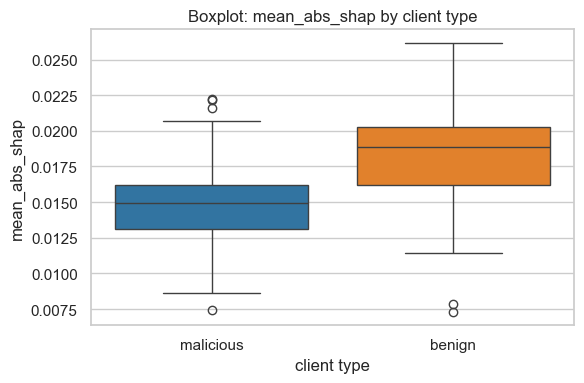

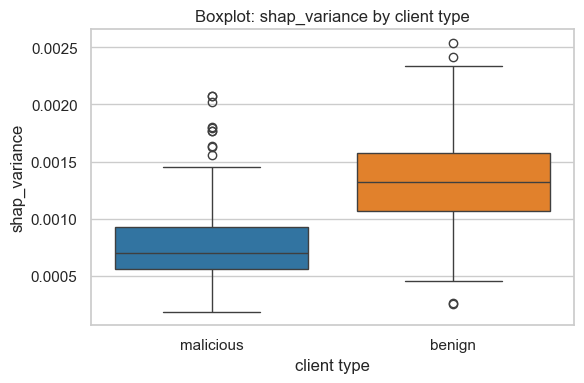

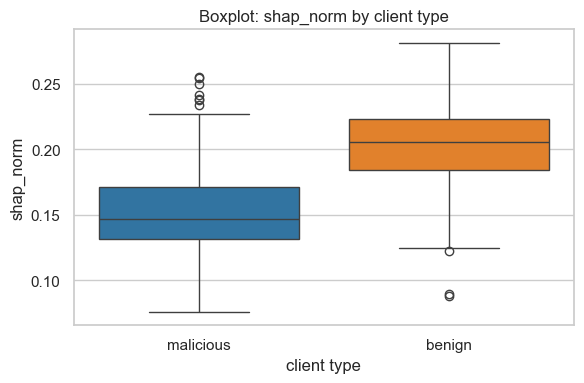

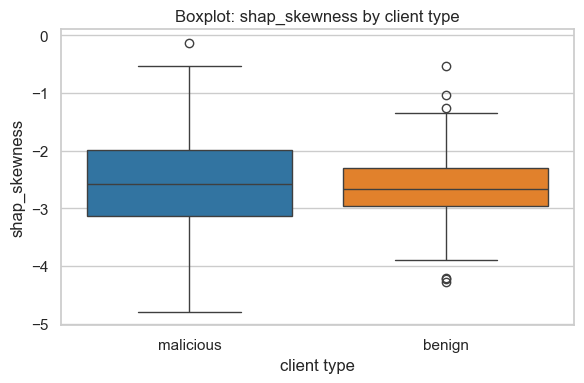

In [239]:
# Boxplots comparing benign vs malicious for each metric
for m in ALL_METRICS:
    if df_stats.empty:
        print("df_stats is empty; skipping plotting for", m)
        continue
    plt.figure(figsize=(6, 4))
    ax = sns.boxplot(x="label", y=m, data=df_stats, palette=["tab:blue", "tab:orange"])
    ax.set_title(f"Boxplot: {m} by client type")
    plt.xlabel("client type")
    plt.ylabel(m)
    plt.tight_layout()
    plt.show()

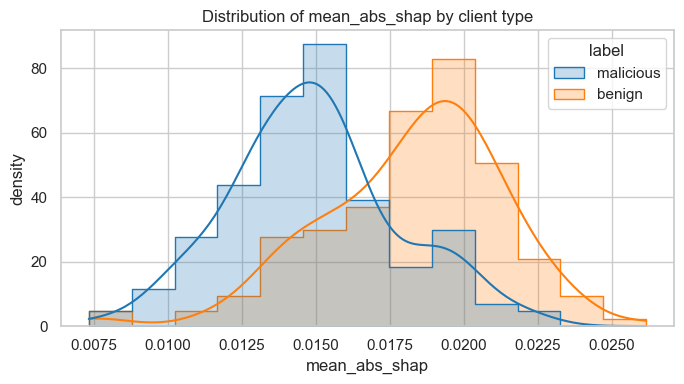

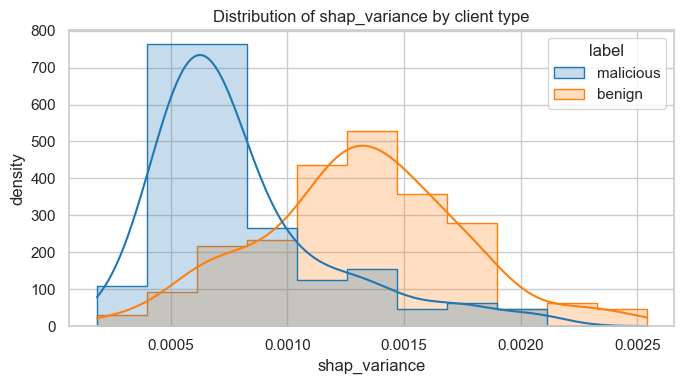

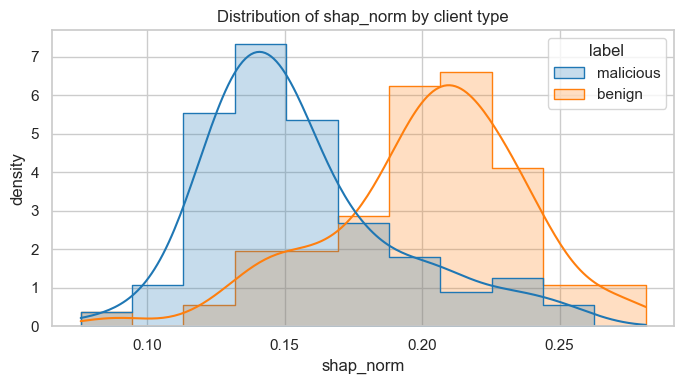

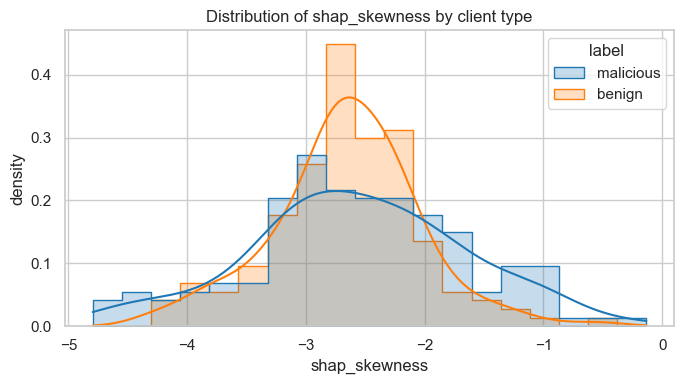

In [240]:
# Histograms / KDE plots for each metric separated by label
for m in ALL_METRICS:
    if df_stats.empty:
        continue
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=df_stats,
        x=m,
        hue="label",
        kde=True,
        element="step",
        stat="density",
        palette=["tab:blue", "tab:orange"],
    )
    plt.title(f"Distribution of {m} by client type")
    plt.xlabel(m)
    plt.ylabel("density")
    plt.tight_layout()
    plt.show()

In [241]:
# Statistical difference testing and effect sizes for benign vs malicious clients
# FIX: shap_skewness now included so all four metrics are tested.
# FIX: Bonferroni correction applied to control family-wise error rate.


def cliffs_delta(x, y_arr):
    x = np.asarray(x)
    y_arr = np.asarray(y_arr)
    if x.size == 0 or y_arr.size == 0:
        return np.nan
    gt = sum(np.sum(xv > y_arr) for xv in x)
    lt = sum(np.sum(xv < y_arr) for xv in x)
    return float((gt - lt) / (x.size * y_arr.size))


def permutation_test_statistic(x, y_arr):
    return float(np.median(x) - np.median(y_arr))


def permutation_pvalue(x, y_arr, n_permutations=5000, seed=42):
    x = np.asarray(x)
    y_arr = np.asarray(y_arr)
    if x.size == 0 or y_arr.size == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    observed = permutation_test_statistic(x, y_arr)
    combined = np.concatenate([x, y_arr])
    n_x = x.size
    extreme = sum(
        1
        for _ in range(n_permutations)
        if abs(
            permutation_test_statistic((p := rng.permutation(combined))[:n_x], p[n_x:])
        )
        >= abs(observed)
    )
    return float(observed), float((extreme + 1) / (n_permutations + 1))


results = []
for metric in ALL_METRICS:
    if df_stats.empty:
        results.append(
            {
                k: np.nan
                for k in [
                    "metric",
                    "benign_median",
                    "malicious_median",
                    "median_diff",
                    "mw_stat",
                    "mw_pvalue",
                    "perm_stat",
                    "perm_pvalue",
                    "rank_biserial",
                    "cliffs_delta",
                ]
            }
        )
        results[-1]["metric"] = metric
        continue

    grp_ben = df_stats.loc[df_stats["label"] == "benign", metric].dropna().values
    grp_mal = df_stats.loc[df_stats["label"] == "malicious", metric].dropna().values

    try:
        mw_res = stats.mannwhitneyu(grp_ben, grp_mal, alternative="two-sided")
        mw_stat, mw_p = float(mw_res.statistic), float(mw_res.pvalue)
    except Exception:
        mw_stat, mw_p = np.nan, np.nan

    perm_stat, perm_p = permutation_pvalue(
        grp_ben, grp_mal, n_permutations=5000, seed=42
    )

    n_ben, n_mal = grp_ben.size, grp_mal.size
    rank_biserial = (
        float((2 * mw_stat) / (n_ben * n_mal) - 1)
        if np.isfinite(mw_stat) and n_ben > 0 and n_mal > 0
        else np.nan
    )

    results.append(
        {
            "metric": metric,
            "benign_median": float(np.median(grp_ben)) if n_ben else np.nan,
            "malicious_median": float(np.median(grp_mal)) if n_mal else np.nan,
            "median_diff": float(np.median(grp_ben) - np.median(grp_mal))
            if n_ben and n_mal
            else np.nan,
            "mw_stat": mw_stat,
            "mw_pvalue": mw_p,
            "perm_stat": perm_stat,
            "perm_pvalue": perm_p,
            "rank_biserial": rank_biserial,
            "cliffs_delta": cliffs_delta(grp_ben, grp_mal),
        }
    )

df_tests = pd.DataFrame(results)

# FIX: Bonferroni correction — adjust significance threshold for number of tests
n_tests = len(ALL_METRICS)
bonferroni_alpha = 0.05 / n_tests
df_tests["mw_sig_bonferroni"] = df_tests["mw_pvalue"] < bonferroni_alpha
df_tests["perm_sig_bonferroni"] = df_tests["perm_pvalue"] < bonferroni_alpha

display(df_tests)
print(
    f"\nBonferroni-corrected significance threshold "
    f"(α=0.05 / {n_tests} tests): {bonferroni_alpha:.4f}"
)

,metric,benign_median,malicious_median,median_diff,mw_stat,mw_pvalue,perm_stat,perm_pvalue,rank_biserial,cliffs_delta,mw_sig_bonferroni,perm_sig_bonferroni
0,mean_abs_shap,0.018853,0.014916,0.003937,17852.0,1.531066e-18,0.003937,0.000200,0.586844,0.586844,True,True
1,shap_variance,0.001322,0.000696,0.000626,18491.0,5.528083e-22,0.000626,0.000200,0.643644,0.643644,True,True
2,shap_norm,0.205300,0.146968,0.058332,18590.0,1.518552e-22,0.058332,0.000200,0.652444,0.652444,True,True
3,shap_skewness,-2.658964,-2.588411,-0.070553,10540.0,3.449514e-01,-0.070553,0.383723,-0.063111,-0.063111,False,False



Bonferroni-corrected significance threshold (α=0.05 / 4 tests): 0.0125


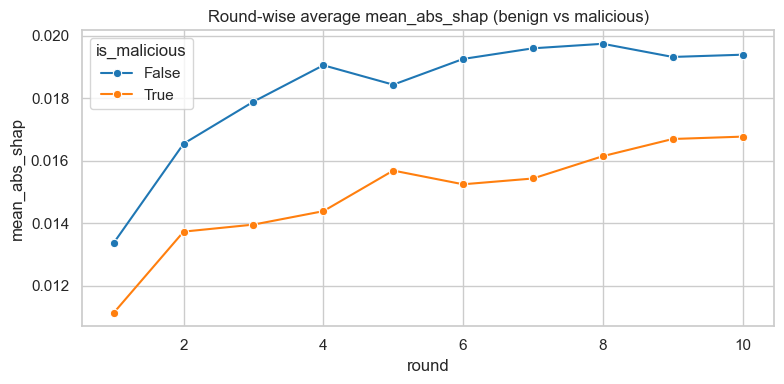

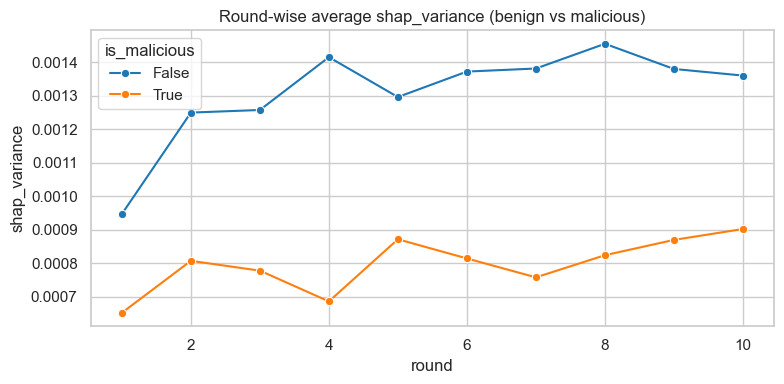

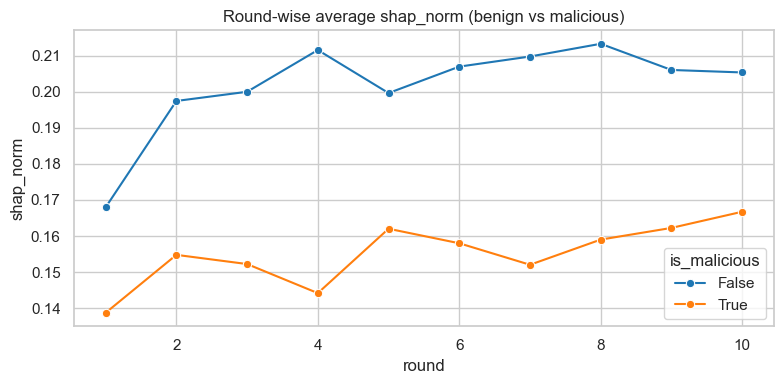

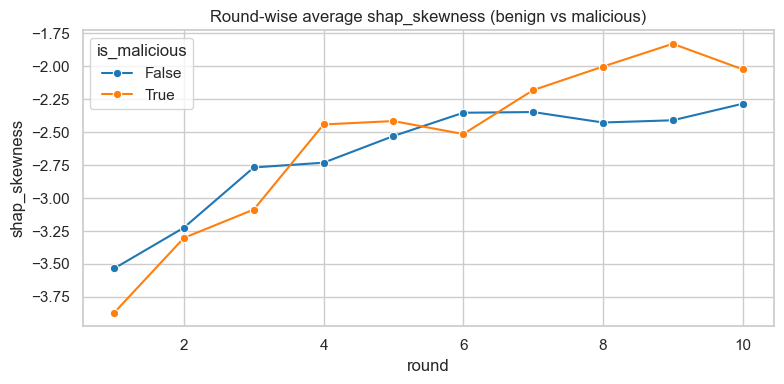

In [242]:
# Evolution over rounds: average metrics for benign vs malicious
if not df_stats.empty:
    agg = df_stats.groupby(["round", "is_malicious"])[ALL_METRICS].mean().reset_index()
    for m in ALL_METRICS:
        plt.figure(figsize=(8, 4))
        sns.lineplot(
            data=agg,
            x="round",
            y=m,
            hue="is_malicious",
            marker="o",
            palette=["tab:blue", "tab:orange"],
        )
        plt.title(f"Round-wise average {m} (benign vs malicious)")
        plt.xlabel("round")
        plt.ylabel(m)
        plt.tight_layout()
        plt.show()
else:
    print("df_stats empty; skipping round evolution plots")

Explained variance ratio: [0.63816376 0.1408542 ]
PC1 explains 63.8% of variance


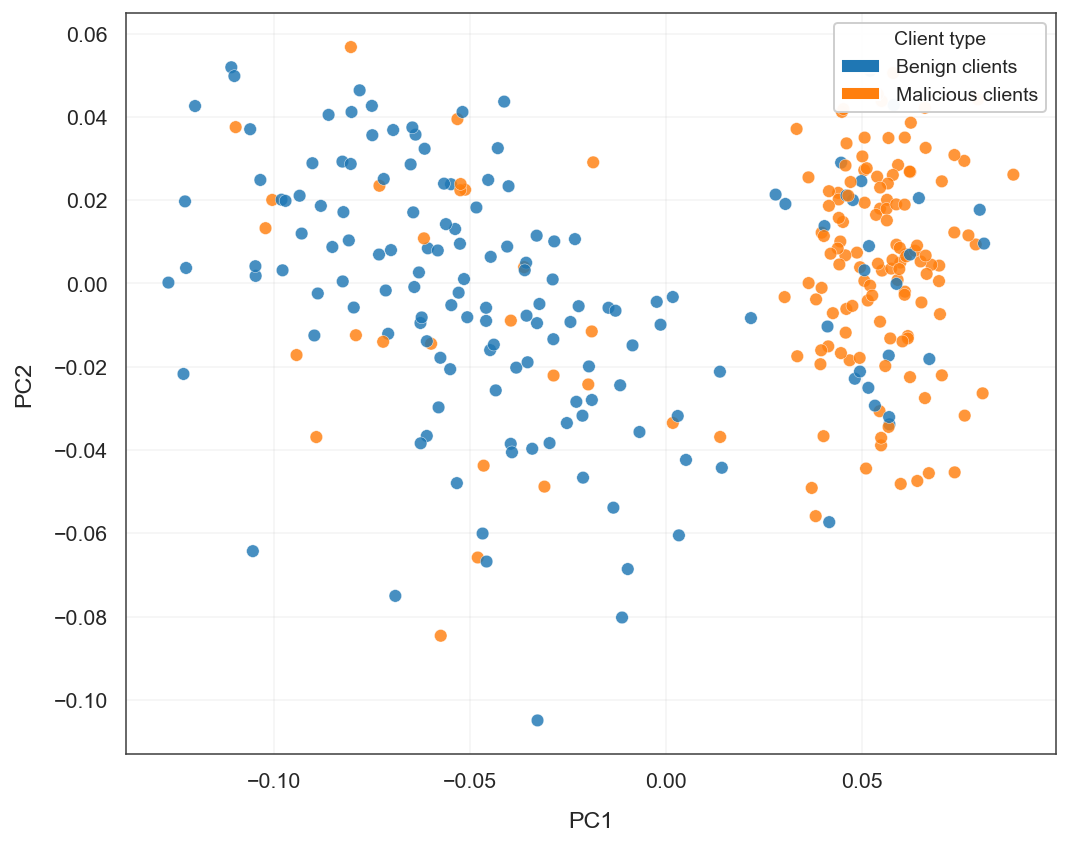

In [243]:
# PCA visualization on raw SHAP vectors (2 components)
if X.size == 0:
    print("Feature matrix X is empty; skipping PCA and t-SNE")
else:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    df_pca = pd.DataFrame(X_pca, columns=["pc1", "pc2"])
    df_pca["is_malicious"] = y
    df_pca["label"] = df_pca["is_malicious"].map(
        {True: "Malicious clients", False: "Benign clients"}
    )

    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
    print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")

    from matplotlib.patches import Patch

    fig, ax = plt.subplots(figsize=(7.8, 6.2), dpi=140)
    sns.scatterplot(
        data=df_pca,
        x="pc1",
        y="pc2",
        hue="label",
        palette={"Benign clients": "tab:blue", "Malicious clients": "tab:orange"},
        alpha=0.82,
        s=42,
        edgecolor="white",
        linewidth=0.25,
        legend=False,
        ax=ax,
    )
    ax.set_xlabel("PC1", labelpad=10)
    ax.set_ylabel("PC2", labelpad=10)
    legend_handles = [
        Patch(facecolor="tab:blue", edgecolor="white", label="Benign clients"),
        Patch(facecolor="tab:orange", edgecolor="white", label="Malicious clients"),
    ]
    ax.legend(
        handles=legend_handles,
        title="Client type",
        loc="upper right",
        frameon=True,
        fancybox=True,
        framealpha=0.96,
        edgecolor="0.8",
        fontsize=10,
        title_fontsize=10,
    )
    ax.grid(True, alpha=0.18)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("0.25")
    # ax.set_title('PCA of SHAP vectors (2 components)')
    plt.tight_layout()
    plt.show()

Explained variance ratio: [0.63816376 0.1408542  0.07109303]


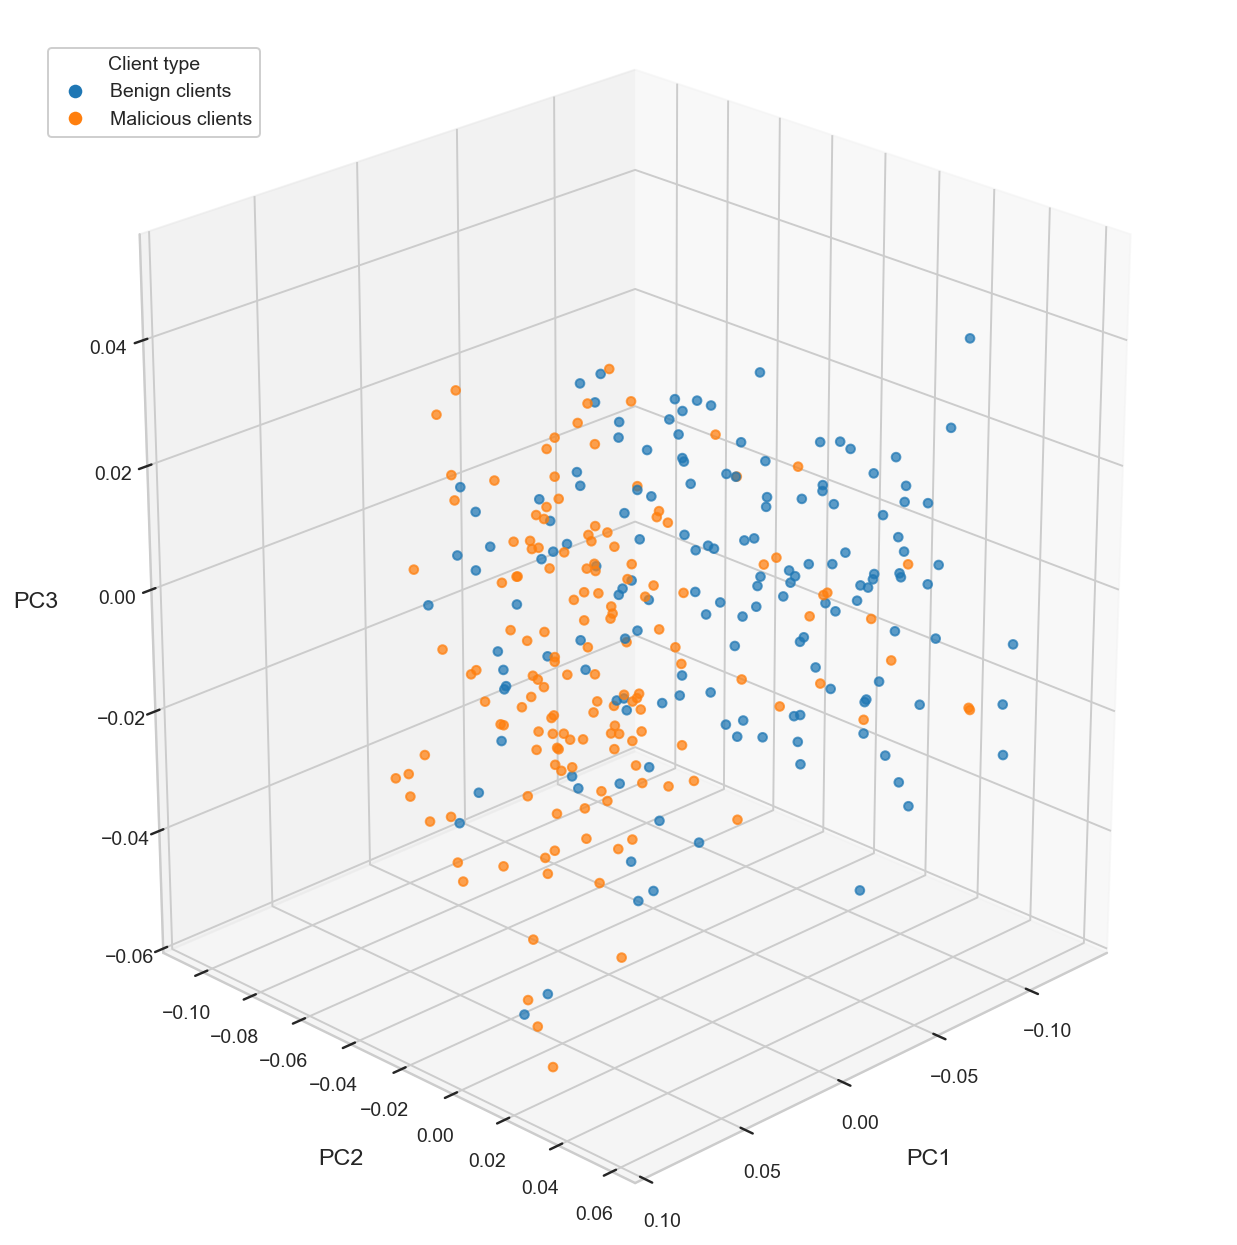

In [244]:
# PCA visualization (3 components) — 3D scatter
if X.size == 0:
    print("Feature matrix X is empty; skipping 3D PCA")
else:
    pca3 = PCA(n_components=3)
    X_pca3 = pca3.fit_transform(X)
    df_pca3 = pd.DataFrame(X_pca3, columns=["pc1", "pc2", "pc3"])
    df_pca3["is_malicious"] = y
    df_pca3["label"] = df_pca3["is_malicious"].map(
        {True: "Malicious clients", False: "Benign clients"}
    )

    print(f"Explained variance ratio: {pca3.explained_variance_ratio_}")

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    from matplotlib.lines import Line2D

    fig = plt.figure(figsize=(12, 9), dpi=140)
    ax = fig.add_subplot(111, projection="3d")
    color_map = df_pca3["label"].map(
        {"Benign clients": "tab:blue", "Malicious clients": "tab:orange"}
    )
    ax.scatter(
        df_pca3["pc1"],
        df_pca3["pc2"],
        df_pca3["pc3"],
        c=color_map,
        alpha=0.72,
        s=20,
        depthshade=True,
    )
    ax.set_xlabel("PC1", labelpad=12)
    ax.set_ylabel("PC2", labelpad=12)
    ax.set_zlabel("PC3", labelpad=18)
    ax.set_box_aspect((1, 1, 1.15))
    ax.view_init(elev=24, azim=45)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.tick_params(axis="z", which="major", labelsize=10)
    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="tab:blue",
            markeredgecolor="white",
            markersize=8,
            label="Benign clients",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="tab:orange",
            markeredgecolor="white",
            markersize=8,
            label="Malicious clients",
        ),
    ]
    ax.legend(
        handles=legend_handles,
        title="Client type",
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        frameon=True,
        fancybox=True,
        framealpha=0.96,
        edgecolor="0.8",
        fontsize=10,
        title_fontsize=10,
    )
    # ax.set_title('3D PCA of SHAP vectors (3 components)')
    plt.tight_layout()
    plt.show()

# PCA

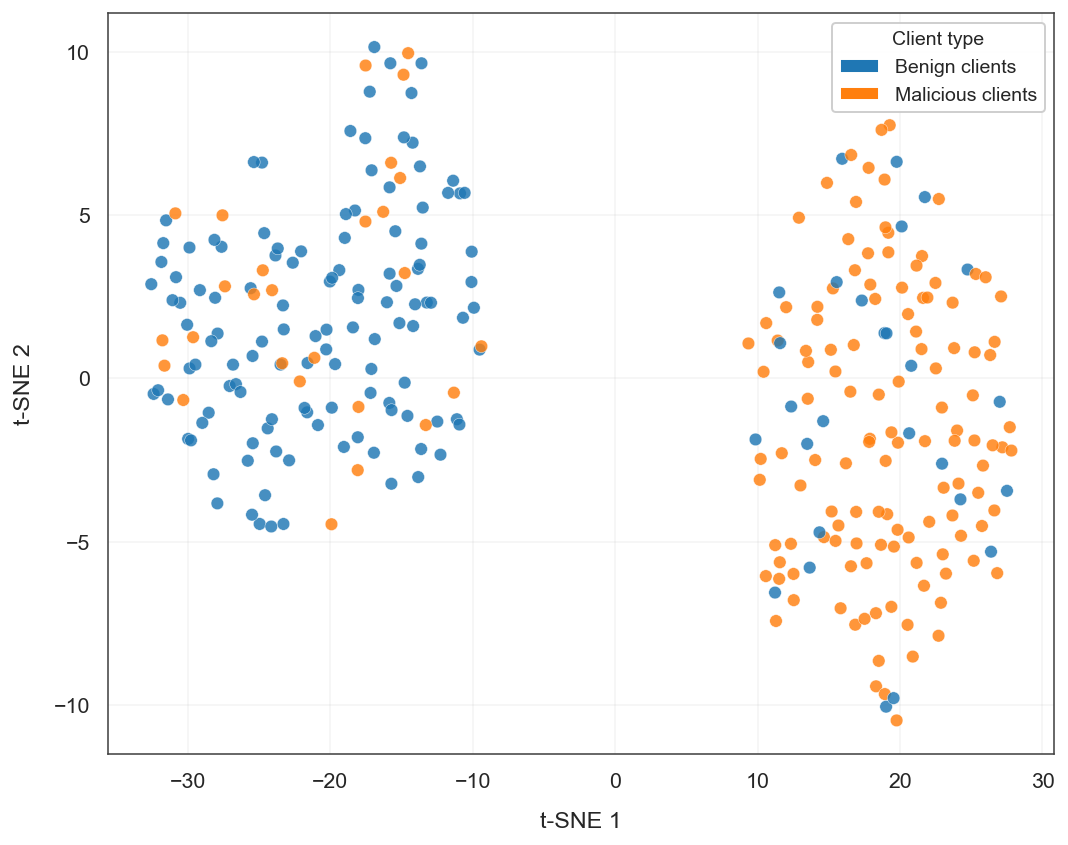

In [245]:
# t-SNE visualization on raw SHAP vectors
# FIX: perplexity increased from 10 to 30 — recommended range for ~900 samples
#      is 30-50; perplexity=10 over-emphasises local structure.
if X.size == 0:
    print("Feature matrix X is empty; skipping t-SNE")
else:
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
    X_tsne = tsne.fit_transform(X)
    df_tsne = pd.DataFrame(X_tsne, columns=["dim1", "dim2"])
    df_tsne["is_malicious"] = y
    df_tsne["label"] = df_tsne["is_malicious"].map(
        {True: "Malicious clients", False: "Benign clients"}
    )

    from matplotlib.patches import Patch

    fig, ax = plt.subplots(figsize=(7.8, 6.2), dpi=140)
    sns.scatterplot(
        data=df_tsne,
        x="dim1",
        y="dim2",
        hue="label",
        palette={"Benign clients": "tab:blue", "Malicious clients": "tab:orange"},
        alpha=0.82,
        s=42,
        edgecolor="white",
        linewidth=0.25,
        legend=False,
        ax=ax,
    )
    ax.set_xlabel("t-SNE 1", labelpad=10)
    ax.set_ylabel("t-SNE 2", labelpad=10)
    legend_handles = [
        Patch(facecolor="tab:blue", edgecolor="white", label="Benign clients"),
        Patch(facecolor="tab:orange", edgecolor="white", label="Malicious clients"),
    ]
    ax.legend(
        handles=legend_handles,
        title="Client type",
        loc="upper right",
        frameon=True,
        fancybox=True,
        framealpha=0.96,
        edgecolor="0.8",
        fontsize=10,
        title_fontsize=10,
    )
    ax.grid(True, alpha=0.18)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("0.25")
    # ax.set_title('t-SNE of SHAP vectors (perplexity=30)')
    plt.tight_layout()
    plt.show()

,representation,benign_mean,malicious_mean,mean_diff,benign_std,malicious_std,separation_score
0,pc1_aligned,1.244684,-1.244684,2.489367,1.706558,1.695252,1.463546
1,mean_abs_shap,0.018267,0.014924,0.003343,0.003059,0.002845,1.131763
2,feature_0_abs,0.020560,0.016031,0.004529,0.010863,0.009236,0.449159


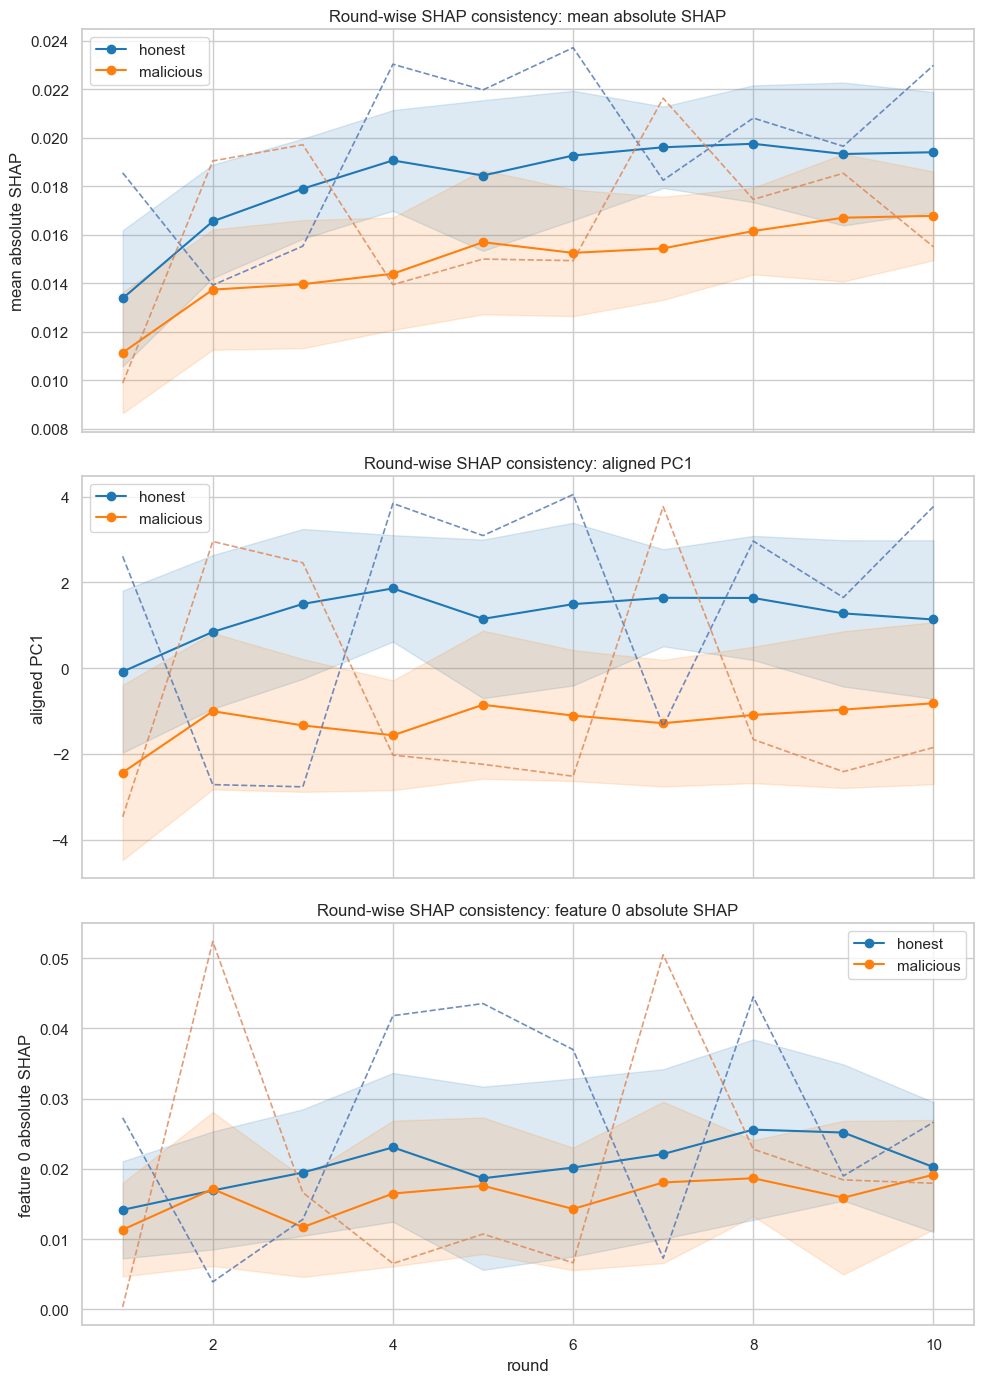

In [246]:
# Round-wise SHAP consistency across honest vs malicious clients
from sklearn.preprocessing import StandardScaler

if "flat" not in globals() or len(flat) == 0:
    flat = flatten_shap_history(shap_history)

round_rows = []
for item in flat:
    sv = np.asarray(item["shap_values"]).reshape(-1)
    if sv.size == 0:
        continue
    round_rows.append(
        {
            "round": int(item["round"]),
            "client_id": str(item["client_id"]),
            "is_malicious": bool(item["is_malicious"]),
            "mean_abs_shap": float(np.mean(np.abs(sv))),
            "feature_0_abs": float(np.abs(sv[0])) if sv.size > 0 else np.nan,
            "feature_0": float(sv[0]) if sv.size > 0 else np.nan,
            "shap_norm": float(np.linalg.norm(sv)),
        }
    )

round_df = pd.DataFrame(round_rows)

if round_df.empty or X.size == 0:
    print("No SHAP data available for round-wise consistency plots")
else:
    X_scaled = StandardScaler().fit_transform(X)
    pc1_scores = PCA(n_components=1).fit_transform(X_scaled).reshape(-1)
    if len(pc1_scores) == len(round_df):
        pc1_aligned = pc1_scores.copy()
        corr = np.corrcoef(pc1_aligned, round_df["mean_abs_shap"].to_numpy())[0, 1]
        if np.isfinite(corr) and corr < 0:
            pc1_aligned = -pc1_aligned
        round_df["pc1_aligned"] = pc1_aligned
    else:
        round_df["pc1_aligned"] = np.nan

    client_counts = (
        round_df.groupby(["client_id", "is_malicious"])
        .size()
        .reset_index(name="n_rounds")
    )
    honest_client = (
        client_counts.loc[client_counts["is_malicious"] == False]
        .sort_values(["n_rounds", "client_id"], ascending=[False, True])
        .head(1)
    )
    malicious_client = (
        client_counts.loc[client_counts["is_malicious"] == True]
        .sort_values(["n_rounds", "client_id"], ascending=[False, True])
        .head(1)
    )

    selected_clients = []
    if not honest_client.empty:
        selected_clients.append((honest_client.iloc[0]["client_id"], False))
    if not malicious_client.empty:
        selected_clients.append((malicious_client.iloc[0]["client_id"], True))

    group_round_summary = (
        round_df.groupby(["round", "is_malicious"])[
            ["mean_abs_shap", "feature_0_abs", "pc1_aligned"]
        ]
        .agg(["mean", "std"])
        .reset_index()
    )
    group_round_summary.columns = [
        "round",
        "is_malicious",
        "mean_abs_shap_mean",
        "mean_abs_shap_std",
        "feature_0_abs_mean",
        "feature_0_abs_std",
        "pc1_aligned_mean",
        "pc1_aligned_std",
    ]

    representation_rows = []
    representation_specs = [
        ("mean_abs_shap", "mean_abs_shap"),
        ("pc1_aligned", "pc1_aligned"),
        ("feature_0_abs", "feature_0_abs"),
    ]
    for metric_name, column_name in representation_specs:
        benign_values = (
            round_df.loc[~round_df["is_malicious"], column_name].dropna().to_numpy()
        )
        malicious_values = (
            round_df.loc[round_df["is_malicious"], column_name].dropna().to_numpy()
        )
        if benign_values.size == 0 or malicious_values.size == 0:
            continue
        pooled_std = (
            np.sqrt(
                (
                    (benign_values.size - 1) * np.var(benign_values, ddof=1)
                    + (malicious_values.size - 1) * np.var(malicious_values, ddof=1)
                )
                / max(benign_values.size + malicious_values.size - 2, 1)
            )
            if benign_values.size > 1 and malicious_values.size > 1
            else np.nan
        )
        separation = (
            float(
                np.abs(np.mean(benign_values) - np.mean(malicious_values)) / pooled_std
            )
            if np.isfinite(pooled_std) and pooled_std > 0
            else np.nan
        )
        representation_rows.append(
            {
                "representation": metric_name,
                "benign_mean": float(np.mean(benign_values)),
                "malicious_mean": float(np.mean(malicious_values)),
                "mean_diff": float(np.mean(benign_values) - np.mean(malicious_values)),
                "benign_std": float(np.std(benign_values, ddof=1))
                if benign_values.size > 1
                else 0.0,
                "malicious_std": float(np.std(malicious_values, ddof=1))
                if malicious_values.size > 1
                else 0.0,
                "separation_score": separation,
            }
        )
    df_round_representation_comparison = (
        pd.DataFrame(representation_rows)
        .sort_values("separation_score", ascending=False)
        .reset_index(drop=True)
    )

    display(df_round_representation_comparison)

    fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=True)
    plot_specs = [
        ("mean_abs_shap", "mean absolute SHAP"),
        ("pc1_aligned", "aligned PC1"),
        ("feature_0_abs", "feature 0 absolute SHAP"),
    ]

    for ax, (column_name, title_label) in zip(axes, plot_specs):
        group_means = (
            round_df.groupby(["round", "is_malicious"])[column_name]
            .mean()
            .reset_index()
        )
        group_stds = (
            round_df.groupby(["round", "is_malicious"])[column_name]
            .std()
            .reset_index()
            .fillna(0.0)
        )
        for is_malicious, color, label in [
            (False, "tab:blue", "honest"),
            (True, "tab:orange", "malicious"),
        ]:
            mean_series = group_means.loc[
                group_means["is_malicious"] == is_malicious
            ].sort_values("round")
            std_series = group_stds.loc[
                group_stds["is_malicious"] == is_malicious
            ].sort_values("round")
            ax.plot(
                mean_series["round"],
                mean_series[column_name],
                color=color,
                marker="o",
                label=label,
            )
            ax.fill_between(
                mean_series["round"].to_numpy(),
                (
                    mean_series[column_name].to_numpy()
                    - std_series[column_name].to_numpy()
                ),
                (
                    mean_series[column_name].to_numpy()
                    + std_series[column_name].to_numpy()
                ),
                color=color,
                alpha=0.15,
            )

        for client_id, is_malicious in selected_clients:
            client_df = round_df[
                (round_df["client_id"] == client_id)
                & (round_df["is_malicious"] == is_malicious)
            ].sort_values("round")
            if client_df.empty:
                continue
            ax.plot(
                client_df["round"],
                client_df[column_name],
                linestyle="--",
                linewidth=1.2,
                alpha=0.8,
            )

        ax.set_title(f"Round-wise SHAP consistency: {title_label}")
        ax.set_ylabel(title_label)
        ax.legend()

    axes[-1].set_xlabel("round")
    plt.tight_layout()
    plt.show()